## Hough Circle Detection / Finde den zu kleinen Kreis im Bild

Diese Beispielübung befasst sich mit der Erkennung von Kreisen in einem Bild mittels der Hough-Transformation. Ziel ist es, den zu kleinen Kreis und den zu großen Kreis im Bild zu identifizieren und hervorzuheben.

In [1]:
# Load Modules
import numpy as np
import cv2
import matplotlib.pyplot as plt

### Erstelle ein Testbild mit 25 Kreisen (5x5 Gitter)

Generiere ein binäres 300×300 Pixel Bild mit 25 Kreisen in einem regelmäßigen Gitter:
- Standarddurchmesser: 40 Pixel (Radius 20px)
- Ein Kreis ist etwas größer: 45 Pixel Durchmesser (Radius 22.5px)
- Ein Kreis ist etwas kleiner: 35 Pixel Durchmesser (Radius 17.5px)

In [5]:
def create_circle_grid_image(img_size=300, grid_size=5, standard_diameter=40, 
                              larger_diameter=30, smaller_diameter=40, line_thickness=1):
    """
    Erstellt ein binäres Bild mit Kreisen in einem regelmäßigen Gitter.
    
    Parameters:
    - img_size: Bildgröße in Pixeln (quadratisch)
    - grid_size: Anzahl der Kreise pro Zeile/Spalte (z.B. 5 für 5x5 = 25 Kreise)
    - standard_diameter: Durchmesser der normalen Kreise
    - larger_diameter: Durchmesser des größeren Kreises
    - smaller_diameter: Durchmesser des kleineren Kreises
    - line_thickness: Liniendicke der Kreisumrisse in Pixeln (1 für dünne Linien)
    
    Returns:
    - Binary image (numpy array uint8)
    """
    
    # Erstelle schwarzes Bild (binär)
    img = np.zeros((img_size, img_size), dtype=np.uint8)
    
    # Berechne Abstände zwischen Kreisen
    spacing = img_size // (grid_size + 1)
    
    # Standard-Radius
    standard_radius = standard_diameter // 2
    larger_radius = larger_diameter // 2
    smaller_radius = smaller_diameter // 2
    
    # Positionen für den größeren und kleineren Kreis (z.B. Position [1,1] und [3,3])
    larger_pos = (1, 1)   # Zweite Zeile, zweite Spalte (0-indiziert)
    smaller_pos = (3, 3)  # Vierte Zeile, vierte Spalte
    
    # Zeichne Kreise im Gitter
    for row in range(grid_size):
        for col in range(grid_size):
            # Berechne Kreismittelpunkt
            center_x = spacing * (col + 1)
            center_y = spacing * (row + 1)
            
            # Bestimme Radius basierend auf Position
            if (row, col) == larger_pos:
                radius = larger_radius
            elif (row, col) == smaller_pos:
                radius = smaller_radius
            else:
                radius = standard_radius
            
            # Zeichne weißen Kreis als Umriss (line_thickness statt -1 für gefüllte Kreise)
            cv2.circle(img, (center_x, center_y), radius, 255, line_thickness)
    
    return img


# Generiere das Bild
binary_image = create_circle_grid_image(
    img_size=300, 
    grid_size=5, 
    standard_diameter=40,
    larger_diameter=45,
    smaller_diameter=35,
    line_thickness=1
)

print(f"Bildgröße: {binary_image.shape}")
print(f"Datentyp: {binary_image.dtype}")
print(f"Min/Max Werte: {binary_image.min()}/{binary_image.max()}")

Bildgröße: (300, 300)
Datentyp: uint8
Min/Max Werte: 0/255


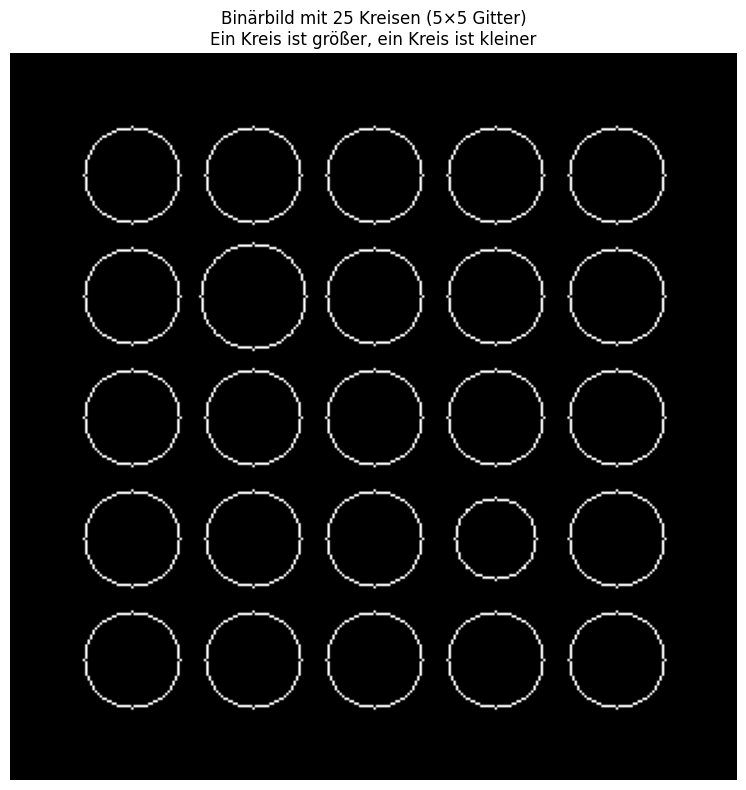

In [6]:
# Zeige das Bild mit Matplotlib
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(binary_image, cmap='gray', vmin=0, vmax=255)
ax.set_title('Binärbild mit 25 Kreisen (5×5 Gitter)\nEin Kreis ist größer, ein Kreis ist kleiner')
ax.axis('off')
plt.tight_layout()
plt.show()

### Optional: Bild speichern

Speichere das generierte Bild als Datei für spätere Verwendung.

In [4]:
# Speichere das Bild (falls gewünscht)
# cv2.imwrite('images/circles_grid.png', binary_image)
# print("Bild gespeichert als 'images/circles_grid.png'")